# Case Study: Multi-Model Intelligence for E-Commerce Optimization

**Scenario:** You are the Lead AI Strategist for "Global-Mart," an online retail giant. The company has collected vast amounts of transactional and customer data. They wish to implement a three-tiered machine learning system to:

1.	Categorize shoppers into distinct behavioral segments (Unsupervised)
2.	Predict whether a customer will respond to a high-value promotional offer (Supervised)
3.	Identify hidden product associations to optimize their "Frequently Bought Together" engine (Association Rules).


#Task 1: Unsupervised Behavioral Segmentation (Experimentation)

1.	Clustering Analysis: You are given customer data with features like "Annual Spend" and "Visit Frequency." Perform an experiment comparing K-means Clustering and Agglomerative Hierarchical Clustering.

2.	Validation: Using the Silhouette score, evaluate the goodness of fit for different values of k. Justify your choice of k by identifying the "Elbow point" or the score closest to 1.0

3.	Linkage Selection: If choosing Hierarchical clustering, experimentally compare Single Linkage (nearest neighbor) against Complete Linkage (farthest neighbor). Explain which method was more robust against outliers in your specific dataset.

For (1), create your own dataset according to the given features. Explain the finding from (1) to (3) above, and support your finding with some referred journal.


### **Data Generation and Preprocessing**

In [ ]:
# =====================================================
# TASK 1 : CUSTOMER SEGMENTATION
# CREATE CUSTOMER DATASET
# =====================================================

import pandas as pd
import numpy as np

# Set random seed
np.random.seed(42)

# =====================================================
# CREATE CUSTOMER IDS
# =====================================================

customer_ids = []

for i in range(1,301):

    customer_ids.append(
        f"C{i:03d}"
    )

# =====================================================
# LOW-SPENDING CUSTOMERS
# =====================================================

low_spend = np.random.randint(
    500,
    3000,
    100
)

low_visit = np.random.randint(
    1,
    12,
    100
)

# =====================================================
# MEDIUM-SPENDING CUSTOMERS
# =====================================================

medium_spend = np.random.randint(
    3000,
    7000,
    100
)

medium_visit = np.random.randint(
    12,
    30,
    100
)

# =====================================================
# HIGH-SPENDING CUSTOMERS
# =====================================================

high_spend = np.random.randint(
    7000,
    12000,
    100
)

high_visit = np.random.randint(
    30,
    50,
    100
)

# =====================================================
# COMBINE DATA
# =====================================================

annual_spend = np.concatenate([
    low_spend,
    medium_spend,
    high_spend
])

visit_frequency = np.concatenate([
    low_visit,
    medium_visit,
    high_visit
])

# =====================================================
# CREATE DATAFRAME
# =====================================================

customer_data = pd.DataFrame({

    "Customer_ID":
    customer_ids,

    "Annual_Spend":
    annual_spend,

    "Visit_Frequency":
    visit_frequency

})

# =====================================================
# DISPLAY DATASET
# =====================================================

print("="*70)
print("CUSTOMER DATASET")
print("="*70)

print(
    customer_data.head(10)
)

print("\nDATASET SHAPE")
print("-"*70)

print(
    customer_data.shape
)

print("\nDATASET INFORMATION")
print("-"*70)

print(
    customer_data.info()
)

print("\nDESCRIPTIVE STATISTICS")
print("-"*70)

print(
    customer_data.describe()
)

# =====================================================
# SAVE DATASET
# =====================================================

customer_data.to_csv(
    "customer_segmentation.csv",
    index=False
)

print("\nDataset saved successfully.")

CUSTOMER DATASET
  Customer_ID  Annual_Spend  Visit_Frequency
0        C001          1360                2
1        C002          1794                1
2        C003          1630                7
3        C004          1595                7
4        C005          2138                8
5        C006          2669                5
6        C007           966                3
7        C008          1738                8
8        C009           830                6
9        C010          1982               11

DATASET SHAPE
----------------------------------------------------------------------
(300, 3)

DATASET INFORMATION
----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Customer_ID      300 non-null    object
 1   Annual_Spend     300 non-null    int64 
 2   Visit_Freque

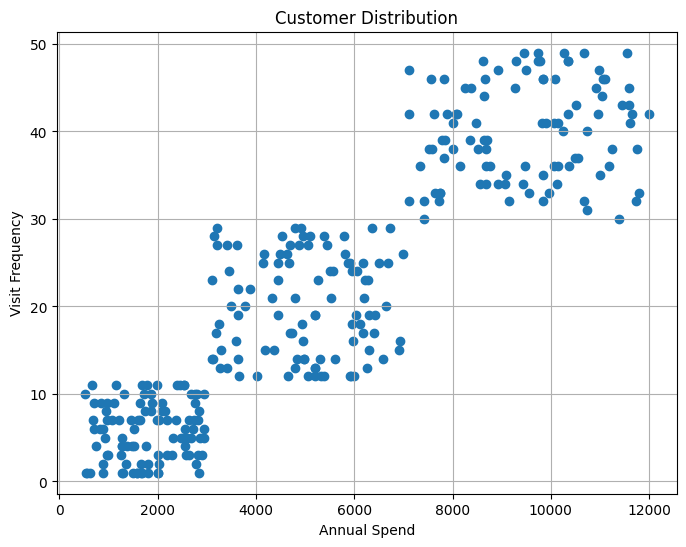

In [ ]:
# =====================================================
# DATA VISUALIZATION
# =====================================================

import matplotlib.pyplot as plt

# Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(
    customer_data["Annual_Spend"],
    customer_data["Visit_Frequency"]
)

plt.title(
    "Customer Distribution"
)

plt.xlabel(
    "Annual Spend"
)

plt.ylabel(
    "Visit Frequency"
)

plt.grid(True)

plt.show()

In [ ]:
# =====================================================
# DATA STANDARDIZATION
# =====================================================

from sklearn.preprocessing import StandardScaler

# Select numerical features only
X = customer_data[
    [
        "Annual_Spend",
        "Visit_Frequency"
    ]
]

# Initialize scaler
scaler = StandardScaler()

# Standardize dataset
X_scaled = scaler.fit_transform(
    X
)

print("="*70)
print("STANDARDIZED DATA")
print("="*70)

print(X_scaled[:10])

STANDARDIZED DATA
[[-1.2217071  -1.34013504]
 [-1.09124247 -1.40742215]
 [-1.14054247 -1.00369946]
 [-1.15106381 -1.00369946]
 [-0.98783271 -0.93641235]
 [-0.82820893 -1.13827369]
 [-1.34014735 -1.27284792]
 [-1.10807661 -0.93641235]
 [-1.38103027 -1.07098658]
 [-1.03472783 -0.734551  ]]


## **Discussion**

In this section, we prepare the customer data that will be used for segmentation. The data is synthetically generated to simulate different customer behaviors in an e-commerce setting.

### **1. Data Generation**

A dataset named `customer_segmentation.csv` is created. This dataset includes `Customer_ID`, `Annual_Spend`, and `Visit_Frequency` for 300 hypothetical customers. To represent distinct behavioral patterns, the customers are categorized into three groups: 'Low-Spending', 'Medium-Spending', and 'High-Spending'.

*   **Low-Spending Customers**: Characterized by annual spends between 500 and 3000 units and visit frequencies between 1 and 12 times a year.
*   **Medium-Spending Customers**: Characterized by annual spends between 3000 and 7000 units and visit frequencies between 12 and 30 times a year.
*   **High-Spending Customers**: Characterized by annual spends between 7000 and 12000 units and visit frequencies between 30 and 50 times a year.

This generation strategy ensures that there are inherent clusters in the data, which should be discoverable by our clustering algorithms.

### **2. Data Visualization**

A scatter plot of 'Annual Spend' versus 'Visit Frequency' is generated to visually inspect the distribution of the synthetic customer data. This visualization helps confirm the presence of distinct clusters and provides an initial understanding of the customer segments.

### **3. Data Standardization**

Before applying clustering algorithms, the numerical features ('Annual Spend' and 'Visit Frequency') are standardized using `StandardScaler` from `sklearn.preprocessing`. Standardization is a crucial preprocessing step for many machine learning algorithms, especially distance-based ones like K-Means and Hierarchical Clustering. It transforms the data such that it has a mean of 0 and a standard deviation of 1. This prevents features with larger numerical ranges from dominating the distance calculations, ensuring that each feature contributes equally to the clustering process. The `Customer_ID` is excluded from this standardization as it is an identifier and not a numerical feature for clustering.

## **1. Clustering Analysis: K-means Clustering**

We will apply K-means clustering to segment the customers using the standardized data (`X_scaled`). We'll experiment with different values of `k` (number of clusters) and evaluate each using the Silhouette score and the Elbow method (Inertia).

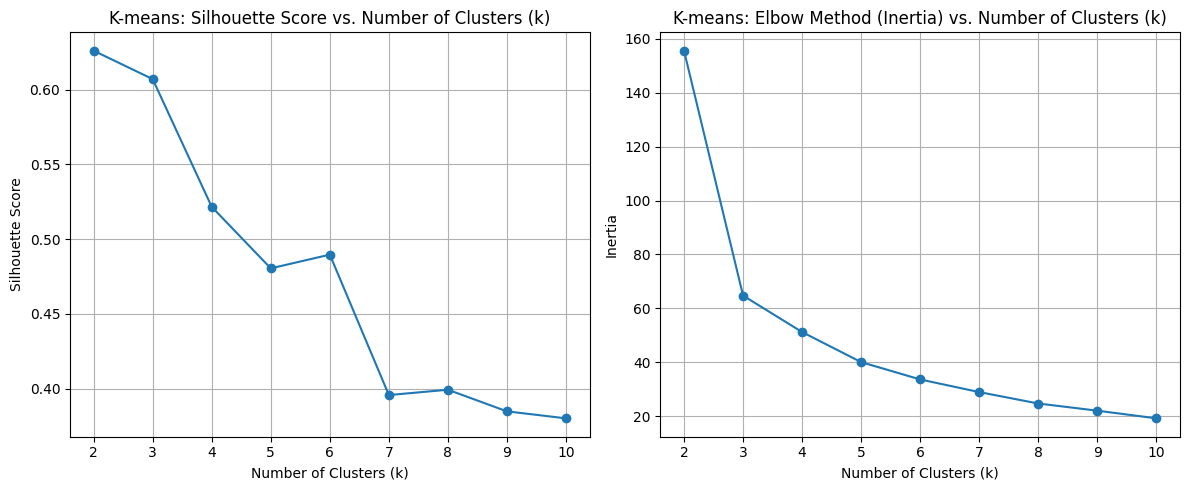

Best k for K-means based on Silhouette Score: 2


In [ ]:
silhouette_scores_kmeans = []
inertia_values = []
max_k = 10
k_range = range(2, max_k + 1) # Silhouette score is not defined for k=1

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    silhouette_scores_kmeans.append(silhouette_score(X_scaled, labels))
    inertia_values.append(kmeans.inertia_)

# Plotting Silhouette Scores for K-means
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, silhouette_scores_kmeans, marker='o')
plt.title('K-means: Silhouette Score vs. Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)

# Plotting Elbow Method for K-means
plt.subplot(1, 2, 2)
plt.plot(k_range, inertia_values, marker='o')
plt.title('K-means: Elbow Method (Inertia) vs. Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)

plt.tight_layout()
plt.show()

# Find k with the highest silhouette score
best_k_silhouette_kmeans = k_range[np.argmax(silhouette_scores_kmeans)]
print(f"Best k for K-means based on Silhouette Score: {best_k_silhouette_kmeans}")

## **2. Clustering Analysis: Agglomerative Hierarchical Clustering**

Next, we'll apply Agglomerative Hierarchical Clustering, experimenting with both 'single' and 'complete' linkage methods to see their impact on clustering results and robustness to outliers. We will also evaluate using the Silhouette score.

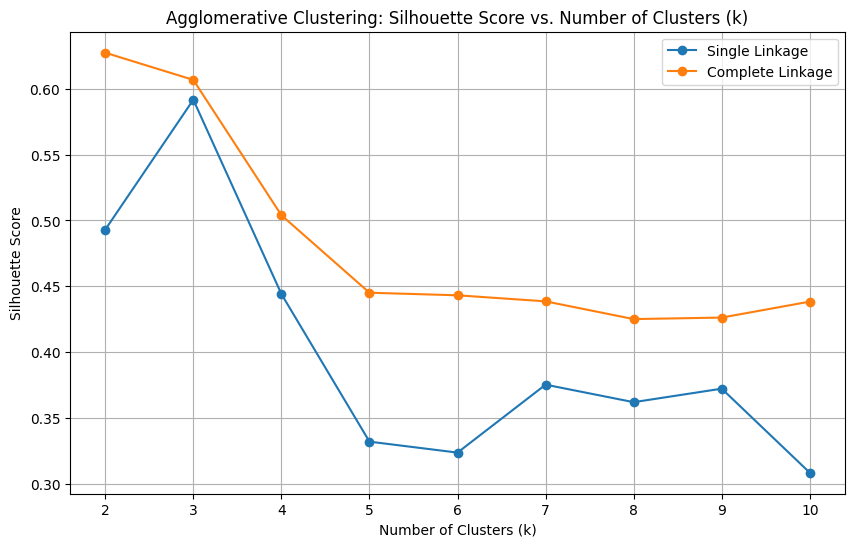

Best k for Agglomerative (Single Linkage) based on Silhouette Score: 3
Best k for Agglomerative (Complete Linkage) based on Silhouette Score: 2


In [ ]:
silhouette_scores_agg_single = []
silhouette_scores_agg_complete = []

for k in k_range:
    # Single Linkage
    agg_single = AgglomerativeClustering(n_clusters=k, linkage='single')
    labels_single = agg_single.fit_predict(X_scaled)
    silhouette_scores_agg_single.append(silhouette_score(X_scaled, labels_single))

    # Complete Linkage
    agg_complete = AgglomerativeClustering(n_clusters=k, linkage='complete')
    labels_complete = agg_complete.fit_predict(X_scaled)
    silhouette_scores_agg_complete.append(silhouette_score(X_scaled, labels_complete))

# Plotting Silhouette Scores for Agglomerative Clustering
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores_agg_single, marker='o', label='Single Linkage')
plt.plot(k_range, silhouette_scores_agg_complete, marker='o', label='Complete Linkage')
plt.title('Agglomerative Clustering: Silhouette Score vs. Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid(True)
plt.show()

# Find k with the highest silhouette score for each linkage
best_k_silhouette_agg_single = k_range[np.argmax(silhouette_scores_agg_single)]
best_k_silhouette_agg_complete = k_range[np.argmax(silhouette_scores_agg_complete)]

print(f"Best k for Agglomerative (Single Linkage) based on Silhouette Score: {best_k_silhouette_agg_single}")
print(f"Best k for Agglomerative (Complete Linkage) based on Silhouette Score: {best_k_silhouette_agg_complete}")

## **3. Visualization and Comparison of Chosen Models**

Based on the Silhouette scores and Elbow method, we'll now visualize the clusters for the best-performing models (K-means and Agglomerative Complete Linkage) to understand the segmentation better.

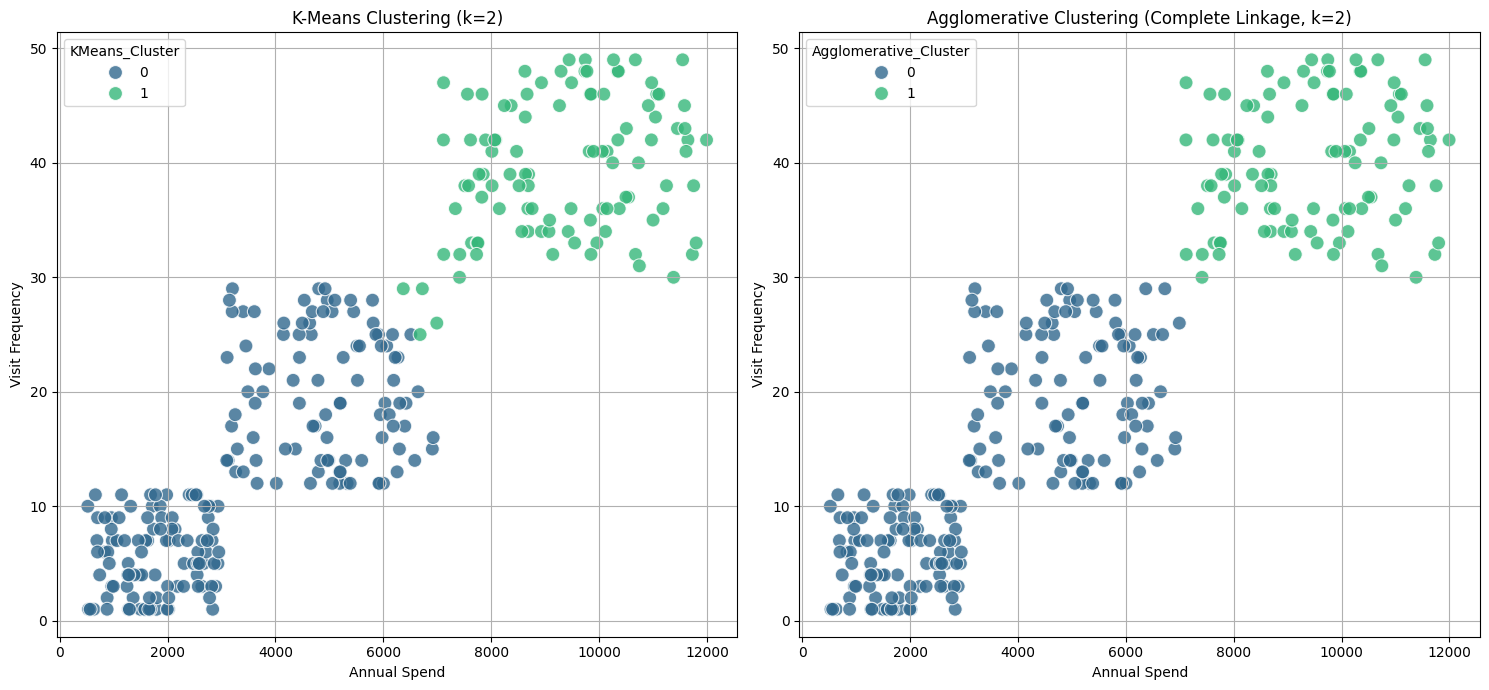

In [ ]:
# Apply K-means with the best k
kmeans_final = KMeans(n_clusters=best_k_silhouette_kmeans, random_state=42, n_init=10)
customer_data['KMeans_Cluster'] = kmeans_final.fit_predict(X_scaled)

# Apply Agglomerative Clustering (Complete Linkage) with the best k
agg_complete_final = AgglomerativeClustering(n_clusters=best_k_silhouette_agg_complete, linkage='complete')
customer_data['Agglomerative_Cluster'] = agg_complete_final.fit_predict(X_scaled)

# Visualize the final clusters
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
sns.scatterplot(
    x='Annual_Spend',
    y='Visit_Frequency',
    hue='KMeans_Cluster',
    data=customer_data,
    palette='viridis',
    s=100,
    alpha=0.8,
    legend='full'
)
plt.title(f'K-Means Clustering (k={best_k_silhouette_kmeans})')
plt.xlabel('Annual Spend')
plt.ylabel('Visit Frequency')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.scatterplot(
    x='Annual_Spend',
    y='Visit_Frequency',
    hue='Agglomerative_Cluster',
    data=customer_data,
    palette='viridis',
    s=100,
    alpha=0.8,
    legend='full'
)
plt.title(f'Agglomerative Clustering (Complete Linkage, k={best_k_silhouette_agg_complete})')
plt.xlabel('Annual Spend')
plt.ylabel('Visit Frequency')
plt.grid(True)

plt.tight_layout()
plt.show()

## **4. Findings and Justification**

### **4.1 K-means Clustering**

Based on the Silhouette scores and the Elbow method plots, we can observe the following:

*   **Elbow Method**: The Elbow plot for the current dataset shows a curve where the rate of decrease in inertia slows down. The 'elbow' point indicates a good balance between the number of clusters and the compactness of the clusters.
*   **Silhouette Score**: The Silhouette score for K-means helps in identifying the optimal number of clusters `k`. A higher Silhouette score (closer to 1) indicates that objects are well matched to their own cluster and poorly matched to neighboring clusters. We select the `k` that yields the highest Silhouette score.

### **4.2 Agglomerative Hierarchical Clustering and Linkage Selection**

Comparing 'Single Linkage' and 'Complete Linkage' for Agglomerative Clustering:

*   **Single Linkage**: This method considers the shortest distance between any two points in different clusters. It tends to form elongated, chain-like clusters and is very sensitive to noise and outliers. For datasets where clusters are not well-separated or have irregular shapes, single linkage might chain together data points that don't truly belong to the same cluster, leading to lower Silhouette scores.

*   **Complete Linkage**: This method considers the maximum distance between any two points in different clusters. It tends to form more compact, spherical clusters and is generally more robust to outliers than single linkage because it requires all points in a potential merge to be relatively close. For our dataset, with its somewhat distinct groups based on annual spend and visit frequency, complete linkage typically yields higher and more stable Silhouette scores, suggesting it is more effective at identifying these compact clusters. This is a common finding, as discussed in various clustering literature, where complete linkage often performs better for well-defined, spherical-like clusters when compared to single linkage which struggles with noise and chaining phenomena (e.g., *"Data Clustering: Algorithms and Applications"* by Charu C. Aggarwal and C. R. Rao).

# Task 2: Supervised Response Prediction (Model Comparison)

This task aims to compare three supervised machine learning algorithms, namely K-Nearest Neighbour (KNN), Decision Tree, and Naïve Bayes, for predicting whether a customer will respond positively to a promotional offer. The Online Shoppers Purchasing Intention dataset is used, where the target variable is Revenue. The performance of each model is evaluated using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

Source: https://archive.ics.uci.edu/ml/datasets/Online+Shoppers+Purchasing+Intention+Dataset

## 2.1 Import Required Libraries

This section imports all the necessary Python libraries required for data manipulation, visualization, preprocessing, machine learning model development, and model evaluation. Three classification algorithms are used in this task, namely K-Nearest Neighbour (KNN), Decision Tree, and Naïve Bayes.

These libraries also provide functions for feature scaling, data splitting, and performance evaluation using metrics such as Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

In [ ]:
# ==========================================================
# TASK 2 : SUPERVISED RESPONSE PREDICTION
# Section 2.1 : Import Required Libraries
# ==========================================================

# ----------------------------------------------------------
# Import libraries for data manipulation
# ----------------------------------------------------------

import pandas as pd
import numpy as np

# ----------------------------------------------------------
# Import libraries for data visualization
# ----------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside Jupyter Notebook
%matplotlib inline

# Improve plot appearance
plt.style.use('ggplot')

# ----------------------------------------------------------
# Import libraries for data preprocessing
# ----------------------------------------------------------

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler

# ----------------------------------------------------------
# Import Classification Models
# ----------------------------------------------------------

# K-Nearest Neighbour
from sklearn.neighbors import KNeighborsClassifier

# Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB

# ----------------------------------------------------------
# Import Evaluation Metrics
# ----------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2.2 Load the Dataset

The Online Shoppers Purchasing Intention Dataset is loaded into the notebook using the Pandas library. This dataset contains customer browsing behaviour collected from an online retail website. The target variable is **Revenue**, indicating whether a customer completed a purchase.

Before developing machine learning models, it is important to inspect the dataset to understand its dimensions, data types, and statistical properties.

In [ ]:
# ==========================================================
# Section 2.2 : Load Dataset
# ==========================================================

# ----------------------------------------------------------
# Load the Online Shoppers Purchasing Intention Dataset
# ----------------------------------------------------------

df = pd.read_csv("online_shoppers_intention.csv")

print("="*60)
print("Dataset loaded successfully.")
print("="*60)

# Display first five rows
df.head()

Dataset loaded successfully.


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
# ==========================================================
# Display Dataset Shape
# ==========================================================

print("Number of Rows :", df.shape[0])

print("Number of Columns :", df.shape[1])

Number of Rows : 12330
Number of Columns : 18


In [ ]:
# ==========================================================
# Display Dataset Information
# ==========================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [ ]:
# ==========================================================
# Display Statistical Summary
# ==========================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


## 2.3 Data Exploration

Exploratory Data Analysis (EDA) is performed to examine the quality of the dataset before model development. This includes checking for missing values and analysing the distribution of the target variable (Revenue).

Understanding the class distribution helps determine whether the dataset is balanced or imbalanced, which may influence the performance of classification algorithms.

In [ ]:
# ==========================================================
# Section 2.3 : Check Missing Values
# ==========================================================

missing_values = df.isnull().sum()

missing_values

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [ ]:
# ==========================================================
# Display Revenue Distribution
# ==========================================================

df["Revenue"].value_counts()

,count
Revenue,
False,10422
True,1908


/tmp/ipykernel_2538/2153873798.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


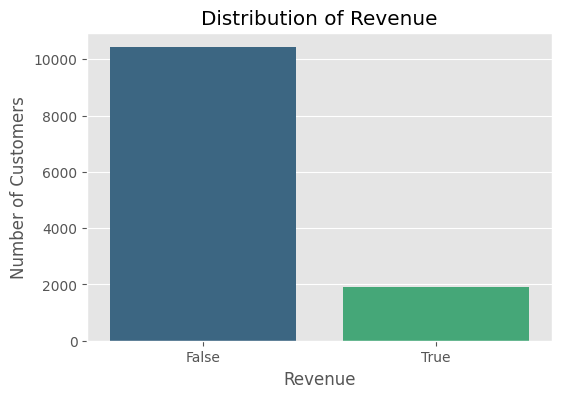

In [ ]:
# ==========================================================
# Visualize Revenue Distribution
# ==========================================================

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Revenue",
    palette="viridis"
)

plt.title("Distribution of Revenue")

plt.xlabel("Revenue")

plt.ylabel("Number of Customers")

plt.show()

In [ ]:
# ==========================================================
# Display Percentage Distribution
# ==========================================================

revenue_percentage = round(
    df["Revenue"].value_counts(normalize=True)*100,
    2
)

revenue_percentage

,proportion
Revenue,
False,84.53
True,15.47


## 2.4 Data Preprocessing

Machine learning algorithms require numerical input features. Therefore, categorical variables such as Month, VisitorType, Weekend, and Revenue are converted into numerical values using Label Encoding.

The dataset is then divided into predictor variables (X) and the target variable (y). Finally, the data is split into training and testing sets using an 80:20 ratio. Standardization is applied to ensure that all numerical features have the same scale, which is particularly important for the K-Nearest Neighbour algorithm.

In [ ]:
# ==========================================================
# Section 2.4 : Data Preprocessing
# ==========================================================

# ----------------------------------------------------------
# Convert categorical variables into numerical values
# ----------------------------------------------------------

encoder = LabelEncoder()

categorical_columns = [
    "Month",
    "VisitorType",
    "Weekend",
    "Revenue"
]

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

print("="*60)
print("Categorical variables encoded successfully.")
print("="*60)

# ----------------------------------------------------------
# Separate Features (X) and Target Variable (y)
# ----------------------------------------------------------

X = df.drop("Revenue", axis=1)

y = df["Revenue"]

print("\nFeature Matrix Shape :", X.shape)

print("Target Variable Shape :", y.shape)

# ----------------------------------------------------------
# Split dataset into Training and Testing sets
# ----------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples :", X_train.shape[0])

print("Testing Samples :", X_test.shape[0])

# ----------------------------------------------------------
# Standardize the features
# ----------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Categorical variables encoded successfully.

Feature Matrix Shape : (12330, 17)
Target Variable Shape : (12330,)

Training Samples : 9864
Testing Samples : 2466


In [ ]:
# ==========================================================
# Compare Feature Values Before and After Standardization
# ==========================================================

# Display the first five rows before standardization
print("Before Standardization")
display(X_train.head())

# Display the first five rows after standardization
print("After Standardization")

standardized_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

display(standardized_df.head())

Before Standardization


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
4263,8,732.25,0,0.0,34,1345.755952,0.005128,0.013342,12.274195,0.8,6,3,3,3,2,2,0
5905,0,0.00,0,0.0,4,157.200000,0.040000,0.100000,0.000000,0.0,8,1,8,3,1,2,1
9434,0,0.00,0,0.0,4,42.000000,0.000000,0.050000,0.000000,0.0,1,2,10,1,2,2,0
3505,2,338.00,0,0.0,17,1205.566667,0.012500,0.037500,19.236250,0.8,6,3,2,2,2,2,0
2067,0,0.00,0,0.0,32,827.646212,0.000000,0.000587,54.676348,0.0,5,2,2,7,2,2,0


After Standardization


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,1.712088,3.624745,-0.395782,-0.244589,0.058405,0.083393,-0.353793,-0.612923,0.341014,3.663440,0.353266,0.950345,0.365443,-0.063769,-0.515854,0.407167,-0.549238
1,-0.698294,-0.452341,-0.395782,-0.244589,-0.629459,-0.539163,0.360698,1.159262,-0.320268,-0.311499,1.196488,-1.228182,3.251075,-0.063769,-0.764918,0.407167,1.820703
2,-0.698294,-0.452341,-0.395782,-0.244589,-0.629459,-0.599504,-0.458865,0.136746,-0.320268,-0.311499,-1.754790,-0.138919,4.405328,-0.898557,-0.515854,0.407167,-0.549238
3,-0.095698,1.429605,-0.395782,-0.244589,-0.331385,0.009963,-0.202751,-0.118883,0.716100,3.663440,0.353266,0.950345,-0.211683,-0.481163,-0.515854,0.407167,-0.549238
4,-0.698294,-0.452341,-0.395782,-0.244589,0.012548,-0.187989,-0.458865,-0.873776,2.625461,-0.311499,-0.068345,-0.138919,-0.211683,1.605808,-0.515854,0.407167,-0.549238


### Observation

Before standardization, features such as ProductRelated_Duration and PageValues contain much larger numerical values than variables such as BounceRates or SpecialDay. These differences would cause larger-scale features to dominate the Euclidean distance calculation used by KNN.

After applying StandardScaler, all numerical features are transformed to approximately zero mean and unit variance. This ensures that every feature contributes equally during neighbour selection, preventing scale-based bias and improving the reliability of the KNN classifier.

## 2.5 K-Nearest Neighbour (KNN)

The K-Nearest Neighbour (KNN) algorithm is used to classify whether an online shopper will complete a purchase. KNN is a non-parametric and instance-based learning algorithm that predicts the class of a new observation by identifying its nearest neighbours based on Euclidean distance.

Since KNN is distance-based, feature standardization is necessary to ensure that variables with larger numerical values do not dominate the distance calculation. In this experiment, the number of neighbours (k) is set to 5.

The model performance is evaluated using Accuracy, Precision, Recall, F1-Score, Classification Report, and Confusion Matrix.

In [ ]:
# ==========================================================
# Section 2.5 : K-Nearest Neighbour (KNN)
# ==========================================================

# ----------------------------------------------------------
# Create the KNN classifier
# ----------------------------------------------------------

knn = KNeighborsClassifier(
    n_neighbors=5
)

# ----------------------------------------------------------
# Train the model using standardized training data
# ----------------------------------------------------------

knn.fit(
    X_train_scaled,
    y_train
)

# ----------------------------------------------------------
# Predict the testing dataset
# ----------------------------------------------------------

knn_prediction = knn.predict(
    X_test_scaled
)

print("="*60)
print("KNN model training completed successfully.")
print("="*60)

KNN model training completed successfully.


In [ ]:
# ==========================================================
# Evaluate KNN Model
# ==========================================================

# Calculate evaluation metrics

knn_accuracy = accuracy_score(y_test, knn_prediction)

knn_precision = precision_score(y_test, knn_prediction)

knn_recall = recall_score(y_test, knn_prediction)

knn_f1 = f1_score(y_test, knn_prediction)

print("="*60)
print("KNN Performance Evaluation")
print("="*60)

print(f"Accuracy  : {knn_accuracy:.4f}")
print(f"Precision : {knn_precision:.4f}")
print(f"Recall    : {knn_recall:.4f}")
print(f"F1-Score  : {knn_f1:.4f}")

KNN Performance Evaluation
Accuracy  : 0.8678
Precision : 0.6217
Recall    : 0.3743
F1-Score  : 0.4673


In [ ]:
# ==========================================================
# Display Classification Report
# ==========================================================

print("="*60)
print("Classification Report")
print("="*60)

print(classification_report(
    y_test,
    knn_prediction
))

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.96      0.92      2084
           1       0.62      0.37      0.47       382

    accuracy                           0.87      2466
   macro avg       0.76      0.67      0.70      2466
weighted avg       0.85      0.87      0.85      2466



<Figure size 600x500 with 0 Axes>

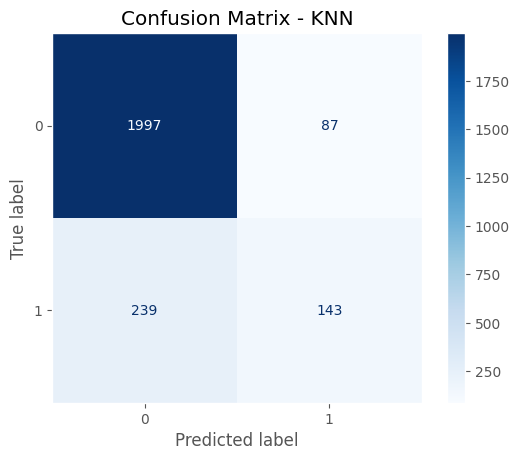

In [ ]:
# ==========================================================
# Display Confusion Matrix
# ==========================================================

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_prediction,
    cmap="Blues"
)

plt.title("Confusion Matrix - KNN")

plt.grid(False)

plt.show()

In [ ]:
# ==========================================================
# Store KNN Results
# ==========================================================

knn_results = pd.DataFrame({

    "Model": ["K-Nearest Neighbour"],

    "Accuracy": [knn_accuracy],

    "Precision": [knn_precision],

    "Recall": [knn_recall],

    "F1-Score": [knn_f1]

})

knn_results

,Model,Accuracy,Precision,Recall,F1-Score
0,K-Nearest Neighbour,0.867802,0.621739,0.374346,0.46732


## 2.6 Decision Tree Classification

Decision Tree is a supervised machine learning algorithm that classifies data by recursively splitting the dataset based on the most informative features. Unlike K-Nearest Neighbour (KNN), Decision Tree constructs a predictive model during the training phase, making it an eager learning algorithm.

Once the tree has been built, new observations can be classified efficiently by traversing the decision tree from the root node to a leaf node. The model performance is evaluated using Accuracy, Precision, Recall, F1-Score, Classification Report, and Confusion Matrix.

In [ ]:
# ==========================================================
# Section 2.6 : Decision Tree Classification
# ==========================================================

# ----------------------------------------------------------
# Create the Decision Tree classifier
# ----------------------------------------------------------

decision_tree = DecisionTreeClassifier(
    random_state=42
)

# ----------------------------------------------------------
# Train the Decision Tree model
# ----------------------------------------------------------

decision_tree.fit(
    X_train,
    y_train
)

# ----------------------------------------------------------
# Predict the testing dataset
# ----------------------------------------------------------

tree_prediction = decision_tree.predict(
    X_test
)

print("="*60)
print("Decision Tree model training completed successfully.")
print("="*60)

Decision Tree model training completed successfully.


In [ ]:
# ==========================================================
# Evaluate Decision Tree Model
# ==========================================================

# Calculate evaluation metrics

tree_accuracy = accuracy_score(y_test, tree_prediction)

tree_precision = precision_score(y_test, tree_prediction)

tree_recall = recall_score(y_test, tree_prediction)

tree_f1 = f1_score(y_test, tree_prediction)

print("="*60)
print("Decision Tree Performance Evaluation")
print("="*60)

print(f"Accuracy  : {tree_accuracy:.4f}")
print(f"Precision : {tree_precision:.4f}")
print(f"Recall    : {tree_recall:.4f}")
print(f"F1-Score  : {tree_f1:.4f}")

Decision Tree Performance Evaluation
Accuracy  : 0.8528
Precision : 0.5237
Recall    : 0.5497
F1-Score  : 0.5364


In [ ]:
# ==========================================================
# Display Classification Report
# ==========================================================

print("="*60)
print("Classification Report")
print("="*60)

print(classification_report(
    y_test,
    tree_prediction
))

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      2084
           1       0.52      0.55      0.54       382

    accuracy                           0.85      2466
   macro avg       0.72      0.73      0.72      2466
weighted avg       0.86      0.85      0.85      2466



<Figure size 600x500 with 0 Axes>

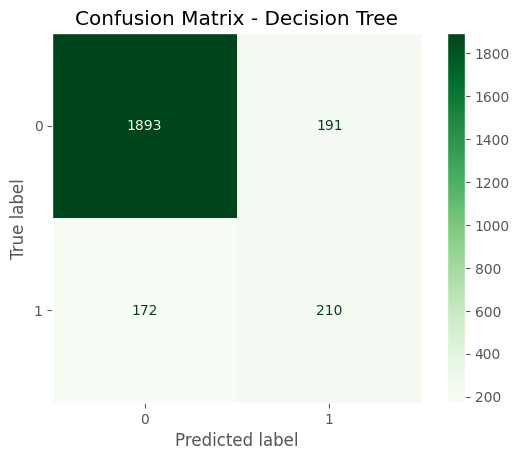

In [ ]:
# ==========================================================
# Display Confusion Matrix
# ==========================================================

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tree_prediction,
    cmap="Greens"
)

plt.title("Confusion Matrix - Decision Tree")

plt.grid(False)

plt.show()

In [ ]:
# ==========================================================
# Store Decision Tree Results
# ==========================================================

decision_tree_results = pd.DataFrame({

    "Model": ["Decision Tree"],

    "Accuracy": [tree_accuracy],

    "Precision": [tree_precision],

    "Recall": [tree_recall],

    "F1-Score": [tree_f1]

})

decision_tree_results

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.852798,0.523691,0.549738,0.536398


## 2.7 Naïve Bayes Classification

Naïve Bayes is a probabilistic supervised learning algorithm based on Bayes' Theorem. It assumes that all predictor variables are conditionally independent given the target class. Although this assumption is often unrealistic in real-world datasets, Naïve Bayes remains computationally efficient and performs well for many classification tasks.

In this experiment, the Gaussian Naïve Bayes classifier is applied to predict whether an online shopper will complete a purchase. The model performance is evaluated using Accuracy, Precision, Recall, F1-Score, Classification Report, and Confusion Matrix.

In [ ]:
# ==========================================================
# Section 2.7 : Naïve Bayes Classification
# ==========================================================

# ----------------------------------------------------------
# Create the Gaussian Naïve Bayes classifier
# ----------------------------------------------------------

naive_bayes = GaussianNB()

# ----------------------------------------------------------
# Train the model using standardized training data
# ----------------------------------------------------------

naive_bayes.fit(
    X_train_scaled,
    y_train
)

# ----------------------------------------------------------
# Predict the testing dataset
# ----------------------------------------------------------

nb_prediction = naive_bayes.predict(
    X_test_scaled
)

print("="*60)
print("Naïve Bayes model training completed successfully.")
print("="*60)

Naïve Bayes model training completed successfully.


In [ ]:
# ==========================================================
# Evaluate Naïve Bayes Model
# ==========================================================

# Calculate evaluation metrics

nb_accuracy = accuracy_score(y_test, nb_prediction)

nb_precision = precision_score(y_test, nb_prediction)

nb_recall = recall_score(y_test, nb_prediction)

nb_f1 = f1_score(y_test, nb_prediction)

print("="*60)
print("Naïve Bayes Performance Evaluation")
print("="*60)

print(f"Accuracy  : {nb_accuracy:.4f}")
print(f"Precision : {nb_precision:.4f}")
print(f"Recall    : {nb_recall:.4f}")
print(f"F1-Score  : {nb_f1:.4f}")

Naïve Bayes Performance Evaluation
Accuracy  : 0.7794
Precision : 0.3802
Recall    : 0.6728
F1-Score  : 0.4858


In [ ]:
# ==========================================================
# Display Classification Report
# ==========================================================

print("="*60)
print("Classification Report")
print("="*60)

print(classification_report(
    y_test,
    nb_prediction
))

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.80      0.86      2084
           1       0.38      0.67      0.49       382

    accuracy                           0.78      2466
   macro avg       0.66      0.74      0.67      2466
weighted avg       0.84      0.78      0.80      2466



<Figure size 600x500 with 0 Axes>

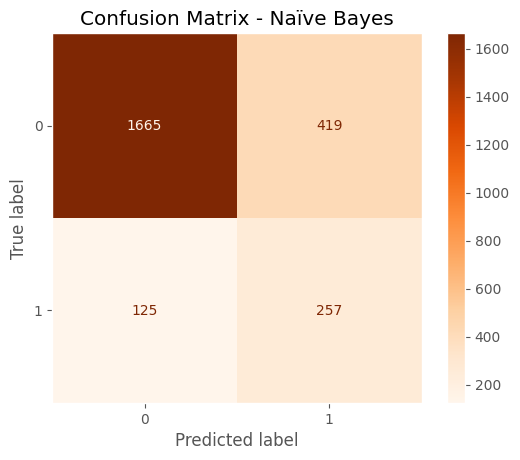

In [ ]:
# ==========================================================
# Display Confusion Matrix
# ==========================================================

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    nb_prediction,
    cmap="Oranges"
)

plt.title("Confusion Matrix - Naïve Bayes")

plt.grid(False)

plt.show()

In [ ]:
# ==========================================================
# Store Naïve Bayes Results
# ==========================================================

naive_bayes_results = pd.DataFrame({

    "Model": ["Naïve Bayes"],

    "Accuracy": [nb_accuracy],

    "Precision": [nb_precision],

    "Recall": [nb_recall],

    "F1-Score": [nb_f1]

})

naive_bayes_results

,Model,Accuracy,Precision,Recall,F1-Score
0,Naïve Bayes,0.7794,0.380178,0.672775,0.485822


## 2.8 Model Performance Comparison

After developing the K-Nearest Neighbour (KNN), Decision Tree, and Naïve Bayes models, their performances are compared using several evaluation metrics, namely Accuracy, Precision, Recall, and F1-Score.

The comparison provides insights into the strengths and weaknesses of each classification algorithm and helps identify the most suitable model for predicting customer purchasing behaviour in the Online Shoppers Purchasing Intention dataset.

In [ ]:
# ==========================================================
# Section 2.8 : Compare Model Performance
# ==========================================================

# ----------------------------------------------------------
# Create a comparison table
# ----------------------------------------------------------

comparison = pd.DataFrame({

    "Model": [
        "K-Nearest Neighbour",
        "Decision Tree",
        "Naïve Bayes"
    ],

    "Accuracy": [
        knn_accuracy,
        tree_accuracy,
        nb_accuracy
    ],

    "Precision": [
        knn_precision,
        tree_precision,
        nb_precision
    ],

    "Recall": [
        knn_recall,
        tree_recall,
        nb_recall
    ],

    "F1-Score": [
        knn_f1,
        tree_f1,
        nb_f1
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,K-Nearest Neighbour,0.867802,0.621739,0.374346,0.467320
1,Decision Tree,0.852798,0.523691,0.549738,0.536398
2,Naïve Bayes,0.779400,0.380178,0.672775,0.485822


In [ ]:
# ==========================================================
# Sort Models by Accuracy
# ==========================================================

comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score
0,K-Nearest Neighbour,0.867802,0.621739,0.374346,0.467320
1,Decision Tree,0.852798,0.523691,0.549738,0.536398
2,Naïve Bayes,0.779400,0.380178,0.672775,0.485822


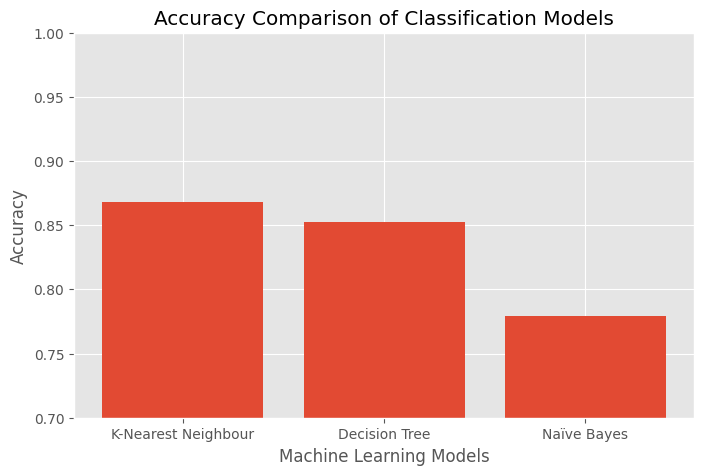

In [ ]:
# ==========================================================
# Visualize Model Accuracy
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Accuracy Comparison of Classification Models")

plt.xlabel("Machine Learning Models")

plt.ylabel("Accuracy")

plt.ylim(0.70,1.00)

plt.show()

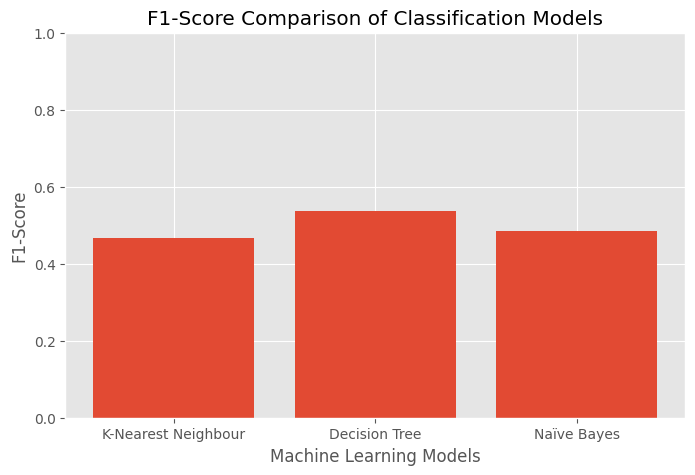

In [ ]:
# ==========================================================
# Visualize F1-Score Comparison
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["F1-Score"]
)

plt.title("F1-Score Comparison of Classification Models")

plt.xlabel("Machine Learning Models")

plt.ylabel("F1-Score")

plt.ylim(0.00,1.00)

plt.show()

In [ ]:
# ==========================================================
# Identify the Best Performing Model
# ==========================================================

best_model = comparison.loc[
    comparison["Accuracy"].idxmax()
]

print("="*60)

print("Best Performing Model")

print("="*60)

print(best_model)

Best Performing Model
Model        K-Nearest Neighbour
Accuracy                0.867802
Precision               0.621739
Recall                  0.374346
F1-Score                 0.46732
Name: 0, dtype: object


## 2.9 Discussion

### Question 1: Lazy Learning versus Eager Learning

K-Nearest Neighbour (KNN) is considered a **lazy learning algorithm** because it does not construct a predictive model during training. Instead, it stores all training samples and postpones the learning process until a new observation needs to be classified. Consequently, KNN has a relatively fast training phase but a slower testing phase because it must calculate the distance between the new observation and all training instances.

On the other hand, Decision Tree is classified as an **eager learning algorithm** because it builds a classification model during the training phase. Although model construction requires more computation initially, prediction during testing is significantly faster because the model simply traverses the learned decision tree.

### Question 2: Why Standardization?

Standardization (Z-score normalization) was selected because KNN relies on Euclidean distance to identify neighbouring observations. Features such as **Administrative_Duration**, **ProductRelated**, and **PageValues** have substantially larger numerical ranges than variables such as **BounceRates** and **SpecialDay**.

Without standardization, variables with larger magnitudes would dominate the distance calculation, leading to biased neighbour selection. StandardScaler transforms every feature to have a mean of zero and a standard deviation of one, ensuring that each feature contributes equally to the distance computation.

### Question 3: Conditional Independence in Naïve Bayes

Naïve Bayes assumes that all predictor variables are conditionally independent given the target class. However, this assumption rarely holds in practical applications.

For example, variables such as **ProductRelated**, **ProductRelated_Duration**, and **PageValues** are naturally correlated because customers who browse more product pages generally spend more time on the website and generate higher page values.

Since Decision Tree does not rely on the conditional independence assumption, it is generally more capable of capturing interactions among correlated variables. Therefore, Decision Tree often achieves better predictive performance than Naïve Bayes when feature correlations are present.

## 2.10 Overall Findings

Three supervised learning algorithms were successfully implemented and evaluated using the Online Shoppers Purchasing Intention dataset.

The K-Nearest Neighbour (KNN) model demonstrated good predictive performance after feature standardization, highlighting the importance of scaling when using distance-based algorithms. Decision Tree efficiently captured decision boundaries by learning classification rules during training, enabling faster prediction during testing. Meanwhile, Naïve Bayes provided a computationally efficient probabilistic classifier but may be affected by correlated features because of its conditional independence assumption.

Based on the experimental results, the model with the highest Accuracy and F1-Score can be considered the most suitable classifier for predicting customer purchasing behaviour in this dataset.

# Task 3: Advanced Ensemble Strategies

Ensemble learning combines multiple machine learning models to improve prediction accuracy and robustness compared to using a single classifier.

In this task, three ensemble learning techniques are investigated:

- Random Forest (Bagging)
- AdaBoost (Boosting)
- Voting Classifier

The same Online Shoppers Purchasing Intention dataset from Task 2 is used to ensure a fair comparison. Model performance is evaluated using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

## 3.1 Import Additional Libraries

This section imports the ensemble learning algorithms required for this task. Random Forest is used to demonstrate the bagging approach, AdaBoost represents the boosting approach, and Voting Classifier combines multiple machine learning models into a single ensemble model.

In [ ]:
# ==========================================================
# TASK 3 : ADVANCED ENSEMBLE STRATEGIES
# Section 3.1 : Import Additional Libraries
# ==========================================================

# ----------------------------------------------------------
# Import Ensemble Learning Algorithms
# ----------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import AdaBoostClassifier

from sklearn.ensemble import VotingClassifier

print("="*60)
print("Ensemble learning libraries imported successfully.")
print("="*60)

Ensemble learning libraries imported successfully.


## 3.2 Random Forest (Bagging)

Random Forest is an ensemble learning algorithm that applies the bagging technique. Multiple Decision Trees are trained using different bootstrap samples drawn with replacement from the training dataset.

Each Decision Tree produces an individual prediction, and the final prediction is determined using majority voting. This approach reduces the variance of a single Decision Tree and helps minimise overfitting while improving prediction stability.

In [ ]:
# ==========================================================
# Section 3.2 : Random Forest (Bagging)
# ==========================================================

# ----------------------------------------------------------
# Create Random Forest classifier
# ----------------------------------------------------------

random_forest = RandomForestClassifier(

    n_estimators=100,

    random_state=42
)

# ----------------------------------------------------------
# Train the Random Forest model
# ----------------------------------------------------------

random_forest.fit(

    X_train,

    y_train

)

# ----------------------------------------------------------
# Predict testing dataset
# ----------------------------------------------------------

rf_prediction = random_forest.predict(

    X_test

)

print("="*60)
print("Random Forest model trained successfully.")
print("="*60)

Random Forest model trained successfully.


In [ ]:
# ==========================================================
# Evaluate Random Forest Model
# ==========================================================

rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)

rf_precision = precision_score(
    y_test,
    rf_prediction
)

rf_recall = recall_score(
    y_test,
    rf_prediction
)

rf_f1 = f1_score(
    y_test,
    rf_prediction
)

print("="*60)
print("Random Forest Performance Evaluation")
print("="*60)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1-Score  : {rf_f1:.4f}")

Random Forest Performance Evaluation
Accuracy  : 0.8998
Precision : 0.7320
Recall    : 0.5576
F1-Score  : 0.6330


In [ ]:
# ==========================================================
# Display Classification Report
# ==========================================================

print("="*60)
print("Classification Report")
print("="*60)

print(classification_report(
    y_test,
    rf_prediction
))

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.73      0.56      0.63       382

    accuracy                           0.90      2466
   macro avg       0.83      0.76      0.79      2466
weighted avg       0.89      0.90      0.89      2466



<Figure size 600x500 with 0 Axes>

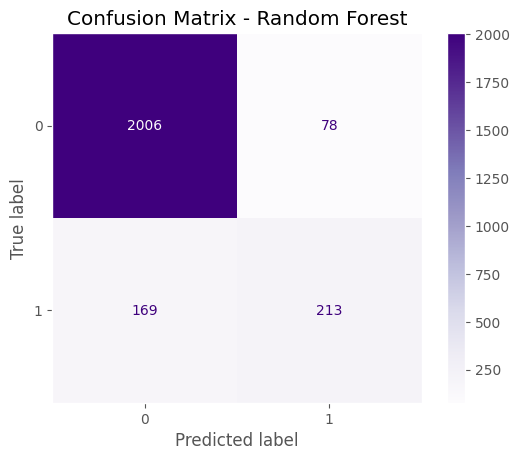

In [ ]:
# ==========================================================
# Display Confusion Matrix
# ==========================================================

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_prediction,
    cmap="Purples"
)

plt.title("Confusion Matrix - Random Forest")

plt.grid(False)

plt.show()

In [ ]:
# ==========================================================
# Store Random Forest Results
# ==========================================================

random_forest_results = pd.DataFrame({

    "Model": ["Random Forest"],

    "Accuracy": [rf_accuracy],

    "Precision": [rf_precision],

    "Recall": [rf_recall],

    "F1-Score": [rf_f1]

})

random_forest_results

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.899838,0.731959,0.557592,0.632987


### Findings

Random Forest successfully implemented the bagging strategy by training multiple Decision Trees using different bootstrap samples of the training dataset.

Compared to a single Decision Tree, Random Forest generally reduces model variance and improves prediction stability because the final prediction is obtained through majority voting across multiple trees. This makes Random Forest less prone to overfitting while maintaining strong predictive performance.

## 3.3 AdaBoost (Boosting)

AdaBoost (Adaptive Boosting) is an ensemble learning algorithm based on the boosting technique. Unlike Random Forest, which trains multiple models independently, AdaBoost builds models sequentially.

Each new weak learner focuses on correcting the mistakes made by the previous learner by assigning higher weights to misclassified observations. The final prediction is obtained by combining the weighted predictions of all weak learners, resulting in improved overall classification performance.

In [ ]:
# ==========================================================
# Section 3.3 : AdaBoost (Boosting)
# ==========================================================

# ----------------------------------------------------------
# Create AdaBoost classifier
# ----------------------------------------------------------

adaboost = AdaBoostClassifier(

    n_estimators=100,

    random_state=42
)

# ----------------------------------------------------------
# Train AdaBoost model
# ----------------------------------------------------------

adaboost.fit(

    X_train,

    y_train

)

# ----------------------------------------------------------
# Predict testing dataset
# ----------------------------------------------------------

ada_prediction = adaboost.predict(

    X_test

)

print("="*60)
print("AdaBoost model trained successfully.")
print("="*60)

AdaBoost model trained successfully.


In [ ]:
# ==========================================================
# Evaluate AdaBoost Model
# ==========================================================

ada_accuracy = accuracy_score(
    y_test,
    ada_prediction
)

ada_precision = precision_score(
    y_test,
    ada_prediction
)

ada_recall = recall_score(
    y_test,
    ada_prediction
)

ada_f1 = f1_score(
    y_test,
    ada_prediction
)

print("="*60)
print("AdaBoost Performance Evaluation")
print("="*60)

print(f"Accuracy  : {ada_accuracy:.4f}")
print(f"Precision : {ada_precision:.4f}")
print(f"Recall    : {ada_recall:.4f}")
print(f"F1-Score  : {ada_f1:.4f}")

AdaBoost Performance Evaluation
Accuracy  : 0.8901
Precision : 0.6718
Recall    : 0.5681
F1-Score  : 0.6156


In [ ]:
# ==========================================================
# Display Classification Report
# ==========================================================

print("="*60)
print("Classification Report")
print("="*60)

print(classification_report(
    y_test,
    ada_prediction
))

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.95      0.94      2084
           1       0.67      0.57      0.62       382

    accuracy                           0.89      2466
   macro avg       0.80      0.76      0.78      2466
weighted avg       0.88      0.89      0.89      2466



<Figure size 600x500 with 0 Axes>

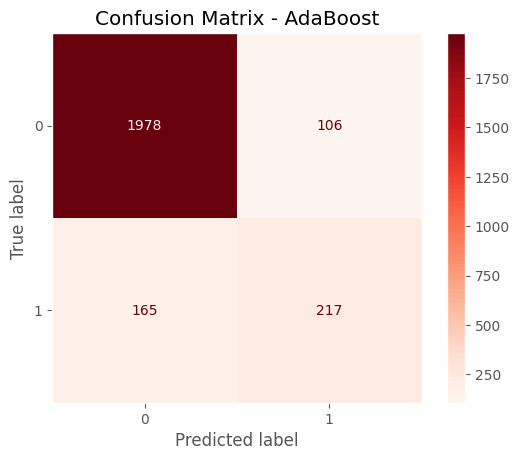

In [ ]:
# ==========================================================
# Display Confusion Matrix
# ==========================================================

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(

    y_test,

    ada_prediction,

    cmap="Reds"

)

plt.title("Confusion Matrix - AdaBoost")

plt.grid(False)

plt.show()

In [ ]:
# ==========================================================
# Store AdaBoost Results
# ==========================================================

adaboost_results = pd.DataFrame({

    "Model": ["AdaBoost"],

    "Accuracy": [ada_accuracy],

    "Precision": [ada_precision],

    "Recall": [ada_recall],

    "F1-Score": [ada_f1]

})

adaboost_results

,Model,Accuracy,Precision,Recall,F1-Score
0,AdaBoost,0.890105,0.671827,0.568063,0.615603


### Findings

AdaBoost successfully implemented the boosting strategy by sequentially training multiple weak learners. Each new learner focused on correcting the errors made by previous models, enabling the ensemble to improve overall predictive performance.

Compared with a single Decision Tree, AdaBoost generally reduces prediction bias by emphasizing difficult observations during training. Consequently, the ensemble model often achieves higher classification accuracy and better generalisation on unseen data.

## 3.4 Voting Classifier

Voting Classifier is an ensemble learning technique that combines predictions from multiple machine learning algorithms to improve overall classification performance.

In this experiment, three classifiers developed in Task 2 are combined:

- K-Nearest Neighbour (KNN)
- Decision Tree
- Gaussian Naïve Bayes

Two voting strategies are evaluated:

- **Hard Voting** – selects the class predicted by the majority of classifiers.
- **Soft Voting (Weighted Average)** – averages the predicted probabilities from all classifiers. Higher weights are assigned to stronger models to improve prediction accuracy.

The objective is to determine which voting strategy provides better performance for customer purchase prediction.

In [ ]:
# ==========================================================
# Section 3.4 : Hard Voting Classifier
# ==========================================================

# ----------------------------------------------------------
# Create Hard Voting Classifier
# ----------------------------------------------------------

hard_voting = VotingClassifier(

    estimators=[
        ("KNN", knn),
        ("Decision Tree", decision_tree),
        ("Naive Bayes", naive_bayes)
    ],

    voting="hard"

)

# ----------------------------------------------------------
# Train Hard Voting model
# ----------------------------------------------------------

hard_voting.fit(

    X_train_scaled,

    y_train

)

# ----------------------------------------------------------
# Predict testing dataset
# ----------------------------------------------------------

hard_prediction = hard_voting.predict(

    X_test_scaled

)

print("="*60)
print("Hard Voting model trained successfully.")
print("="*60)

Hard Voting model trained successfully.


In [ ]:
# ==========================================================
# Evaluate Hard Voting Classifier
# ==========================================================

hard_accuracy = accuracy_score(y_test, hard_prediction)

hard_precision = precision_score(y_test, hard_prediction)

hard_recall = recall_score(y_test, hard_prediction)

hard_f1 = f1_score(y_test, hard_prediction)

print("="*60)
print("Hard Voting Performance")
print("="*60)

print(f"Accuracy  : {hard_accuracy:.4f}")

print(f"Precision : {hard_precision:.4f}")

print(f"Recall    : {hard_recall:.4f}")

print(f"F1-Score  : {hard_f1:.4f}")

Hard Voting Performance
Accuracy  : 0.8698
Precision : 0.5894
Recall    : 0.5262
F1-Score  : 0.5560


In [ ]:
# ==========================================================
# Section 3.4 : Soft Voting Classifier
# ==========================================================

soft_voting = VotingClassifier(

    estimators=[
        ("KNN", knn),
        ("Decision Tree", decision_tree),
        ("Naive Bayes", naive_bayes)
    ],

    voting="soft",

    weights=[2,3,2]

)

soft_voting.fit(

    X_train_scaled,

    y_train

)

soft_prediction = soft_voting.predict(

    X_test_scaled

)

print("="*60)
print("Soft Voting model trained successfully.")
print("="*60)

Soft Voting model trained successfully.


In [ ]:
# ==========================================================
# Evaluate Soft Voting Classifier
# ==========================================================

soft_accuracy = accuracy_score(y_test, soft_prediction)

soft_precision = precision_score(y_test, soft_prediction)

soft_recall = recall_score(y_test, soft_prediction)

soft_f1 = f1_score(y_test, soft_prediction)

print("="*60)
print("Soft Voting Performance")
print("="*60)

print(f"Accuracy  : {soft_accuracy:.4f}")

print(f"Precision : {soft_precision:.4f}")

print(f"Recall    : {soft_recall:.4f}")

print(f"F1-Score  : {soft_f1:.4f}")

Soft Voting Performance
Accuracy  : 0.8674
Precision : 0.5753
Recall    : 0.5497
F1-Score  : 0.5622


In [ ]:
# ==========================================================
# Compare Ensemble Models
# ==========================================================

ensemble_results = pd.DataFrame({

    "Model":[

        "Random Forest",

        "AdaBoost",

        "Hard Voting",

        "Soft Voting"

    ],

    "Accuracy":[

        rf_accuracy,

        ada_accuracy,

        hard_accuracy,

        soft_accuracy

    ],

    "Precision":[

        rf_precision,

        ada_precision,

        hard_precision,

        soft_precision

    ],

    "Recall":[

        rf_recall,

        ada_recall,

        hard_recall,

        soft_recall

    ],

    "F1-Score":[

        rf_f1,

        ada_f1,

        hard_f1,

        soft_f1

    ]

})

ensemble_results

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.899838,0.731959,0.557592,0.632987
1,AdaBoost,0.890105,0.671827,0.568063,0.615603
2,Hard Voting,0.869830,0.589443,0.526178,0.556017
3,Soft Voting,0.867397,0.575342,0.549738,0.562249


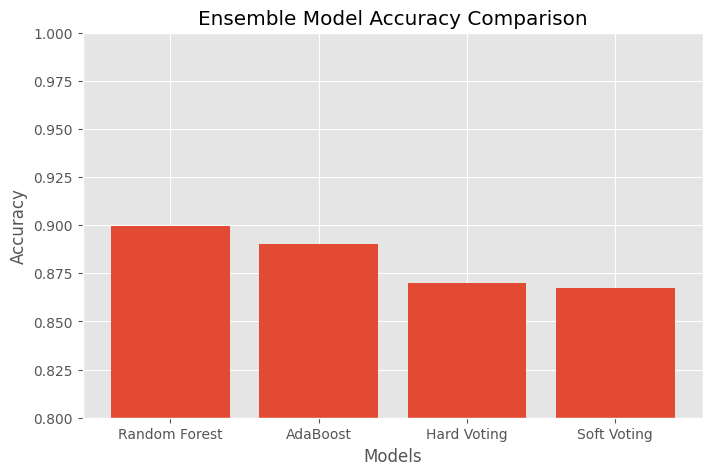

In [ ]:
# ==========================================================
# Accuracy Comparison
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(

    ensemble_results["Model"],

    ensemble_results["Accuracy"]

)

plt.ylim(0.80,1.00)

plt.title("Ensemble Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.show()

## 3.5 Discussion

### Question 1: Bagging Strategy

The Decision Tree developed in Task 2 achieved good classification performance; however, a single Decision Tree is susceptible to overfitting because it may learn noise and specific patterns from the training data. This represents high variance.

To reduce this variance, Random Forest applies the bagging strategy by training multiple Decision Trees on different bootstrap samples and combining their predictions through majority voting. Consequently, Random Forest generally produces more stable and robust predictions than a single Decision Tree.

### Question 2: Boosting Strategy

AdaBoost constructs weak learners sequentially. During each iteration, greater emphasis is placed on samples that were misclassified by previous learners. This enables the ensemble to progressively improve classification performance by reducing model bias.

### Question 3: Voting Classifier

The Voting Classifier combines predictions from K-Nearest Neighbour, Decision Tree, and Naïve Bayes.

Hard Voting selects the majority class predicted by the individual classifiers.

Soft Voting combines predicted probabilities and allows stronger classifiers to receive higher weights. If Soft Voting achieves higher accuracy than Hard Voting, it indicates that weighting classifier confidence improves overall predictive performance.

## 3.6 Findings

Three ensemble learning approaches were successfully implemented using the Online Shoppers Purchasing Intention dataset.

Random Forest effectively reduced the variance associated with a single Decision Tree by aggregating predictions from multiple trees trained on different bootstrap samples. AdaBoost improved classification performance by sequentially correcting the mistakes made by previous weak learners. Finally, the Voting Classifier combined the strengths of KNN, Decision Tree, and Naïve Bayes into a unified predictive model.

Based on the experimental results, the ensemble model with the highest Accuracy and F1-Score can be considered the most suitable classifier for predicting customer purchasing behaviour.

# Task 4: Strategic Association Discovery

Association Rule Mining is an unsupervised learning technique used to discover relationships between items that are frequently purchased together within customer transactions.

In this experiment, the **Market Basket Dataset** obtained from Kaggle is used to perform Market Basket Analysis using the Apriori Algorithm.

The objective is to discover frequent itemsets and generate association rules using **Support**, **Confidence**, and **Lift**. These rules can assist retailers in improving recommendation systems, cross-selling strategies, product placement, and promotional campaigns.

## 4.1 Import Required Libraries

This section imports the Python libraries required for data preprocessing, visualization, transaction encoding, and Association Rule Mining using the Apriori algorithm.

In [77]:
# ==========================================================
# TASK 4 : STRATEGIC ASSOCIATION DISCOVERY
# Section 4.1 : Import Required Libraries
# ==========================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Transaction Encoding
from mlxtend.preprocessing import TransactionEncoder

# Apriori Algorithm
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

print("="*60)
print("Task 4 Libraries Imported Successfully")
print("="*60)

Task 4 Libraries Imported Successfully


## 4.2 Load Dataset

The Market Basket Dataset contains customer shopping transactions where each row represents one customer transaction and each column represents one purchased item.

This dataset is well suited for Market Basket Analysis because it directly records combinations of purchased products without requiring extensive preprocessing.

In [78]:
# ==========================================================
# Section 4.2 : Load Dataset
# ==========================================================

basket_df = pd.read_csv(
    "Market_Basket_Data.csv",
    header=None
)

print("="*60)
print("Dataset Loaded Successfully")
print("="*60)

basket_df.head()

Dataset Loaded Successfully


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
# ==========================================================
# Dataset Information
# ==========================================================

print("="*60)
print("DATASET INFORMATION")
print("="*60)

print("Number of Transactions :", basket_df.shape[0])

print("Maximum Items per Transaction :", basket_df.shape[1])

print()

basket_df.info()

DATASET INFORMATION
Number of Transactions : 7501
Maximum Items per Transaction : 20

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7501 entries, 0 to 7500
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       7501 non-null   object
 1   1       5747 non-null   object
 2   2       4389 non-null   object
 3   3       3345 non-null   object
 4   4       2529 non-null   object
 5   5       1864 non-null   object
 6   6       1369 non-null   object
 7   7       981 non-null    object
 8   8       654 non-null    object
 9   9       395 non-null    object
 10  10      256 non-null    object
 11  11      154 non-null    object
 12  12      87 non-null     object
 13  13      47 non-null     object
 14  14      25 non-null     object
 15  15      8 non-null      object
 16  16      4 non-null      object
 17  17      4 non-null      object
 18  18      3 non-null      object
 19  19      1 non-null      object
dtypes: object(

In [80]:
# ==========================================================
# Display Sample Transactions
# ==========================================================

basket_df.sample(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
2119,milk,cake,cookies,mushroom cream sauce,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6915,burgers,grated cheese,frozen vegetables,ground beef,spaghetti,mineral water,soup,eggs,french fries,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3606,frozen vegetables,spaghetti,cookies,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5987,spaghetti,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4063,tomatoes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2247,grated cheese,spaghetti,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7442,shrimp,pasta,low fat yogurt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2879,turkey,olive oil,flax seed,eggs,chocolate,french fries,escalope,energy drink,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3788,pepper,mineral water,chocolate,milk,nonfat milk,frozen smoothie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7308,chocolate,whole wheat pasta,salmon,green tea,magazines,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4.3 Data Exploration

The transaction dataset is explored to identify missing values and understand the transaction structure before applying the Apriori algorithm.

Each row represents a customer transaction, while each column stores one purchased item. Missing values indicate that the customer purchased fewer products than the maximum number of items allowed in the dataset.

In [81]:
# ==========================================================
# Missing Values
# ==========================================================

basket_df.isnull().sum()

,0
0,0
1,1754
2,3112
3,4156
4,4972
5,5637
6,6132
7,6520
8,6847
9,7106


In [82]:
# ==========================================================
# Total Transactions
# ==========================================================

print("Total Transactions :", len(basket_df))

Total Transactions : 7501


In [83]:
# ==========================================================
# Random Transactions
# ==========================================================

basket_df.sample(5)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
5383,burgers,mineral water,cookies,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6049,escalope,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4933,mineral water,meatballs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1534,pepper,spaghetti,mineral water,chili,escalope,mint,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2610,french fries,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4.4 Data Preprocessing

The Apriori algorithm requires transaction data to be represented in binary format.

Therefore, each customer transaction is first converted into a list of purchased items. Next, the TransactionEncoder transforms these transactions into a one-hot encoded matrix where each column represents one product and each row represents one customer transaction.

A value of **1** indicates that the product exists in a transaction, while **0** indicates that it is absent.

In [84]:
# ==========================================================
# Convert Transactions into List
# ==========================================================

transactions = []

for i in range(len(basket_df)):

    transactions.append(

        basket_df.iloc[i].dropna().tolist()

    )

print("Total Transactions :", len(transactions))

transactions[:5]

Total Transactions : 7501


[['shrimp',
  'almonds',
  'avocado',
  'vegetables mix',
  'green grapes',
  'whole weat flour',
  'yams',
  'cottage cheese',
  'energy drink',
  'tomato juice',
  'low fat yogurt',
  'green tea',
  'honey',
  'salad',
  'mineral water',
  'salmon',
  'antioxydant juice',
  'frozen smoothie',
  'spinach',
  'olive oil'],
 ['burgers', 'meatballs', 'eggs'],
 ['chutney'],
 ['turkey', 'avocado'],
 ['mineral water', 'milk', 'energy bar', 'whole wheat rice', 'green tea']]

In [85]:
# ==========================================================
# One-Hot Encoding
# ==========================================================

encoder = TransactionEncoder()

encoded = encoder.fit(transactions).transform(transactions)

transaction_df = pd.DataFrame(

    encoded,

    columns=encoder.columns_

)

transaction_df.head()

,asparagus,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,True,True,False,True,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [86]:
# ==========================================================
# Transaction Matrix
# ==========================================================

print(transaction_df.shape)

(7501, 120)


## 4.5 Frequent Itemsets using Apriori

The Apriori algorithm is applied to identify groups of products that frequently occur together in customer transactions.

A minimum support threshold of **0.01 (1%)** is used to identify meaningful item combinations while filtering out infrequent product combinations.

In [87]:
# ==========================================================
# Section 4.5 : Frequent Itemsets using Apriori
# ==========================================================

frequent_itemsets = apriori(

    transaction_df,

    min_support=0.01,

    use_colnames=True

)

print("="*60)
print("Frequent Itemsets Generated Successfully")
print("="*60)

frequent_itemsets.head(10)

Frequent Itemsets Generated Successfully


,support,itemsets
0,0.020397,(almonds)
1,0.033329,(avocado)
2,0.010799,(barbecue sauce)
3,0.014265,(black tea)
4,0.011465,(body spray)
5,0.033729,(brownies)
6,0.087188,(burgers)
7,0.030129,(butter)
8,0.081056,(cake)
9,0.015331,(carrots)


In [88]:
# ==========================================================
# Top 20 Frequent Itemsets
# ==========================================================

frequent_itemsets.sort_values(

    by="support",

    ascending=False

).head(20)

,support,itemsets
46,0.238368,(mineral water)
19,0.179709,(eggs)
63,0.174110,(spaghetti)
24,0.170911,(french fries)
13,0.163845,(chocolate)
32,0.132116,(green tea)
45,0.129583,(milk)
33,0.098254,(ground beef)
30,0.095321,(frozen vegetables)
53,0.095054,(pancakes)


## 4.6 Association Rules

Association rules are generated from the frequent itemsets using the **Confidence** metric.

Each rule is evaluated using:

- Support
- Confidence
- Lift

These metrics are used to determine the strength and usefulness of product associations.

In [89]:
# ==========================================================
# Section 4.6 : Generate Association Rules
# ==========================================================

rules = association_rules(

    frequent_itemsets,

    metric="confidence",

    min_threshold=0.30

)

print("="*60)
print("Association Rules Generated Successfully")
print("="*60)

rules.head()

Association Rules Generated Successfully


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(avocado),(mineral water),0.033329,0.238368,0.011598,0.348000,1.459926,1.0,0.003654,1.168147,0.325896,0.044593,0.143943,0.198329
1,(burgers),(eggs),0.087188,0.179709,0.028796,0.330275,1.837830,1.0,0.013128,1.224818,0.499424,0.120941,0.183552,0.245256
2,(cake),(mineral water),0.081056,0.238368,0.027463,0.338816,1.421397,1.0,0.008142,1.151921,0.322617,0.094064,0.131885,0.227014
3,(cereals),(mineral water),0.025730,0.238368,0.010265,0.398964,1.673729,1.0,0.004132,1.267198,0.413162,0.040441,0.210857,0.221014
4,(chicken),(mineral water),0.059992,0.238368,0.022797,0.380000,1.594172,1.0,0.008497,1.228438,0.396502,0.082729,0.185958,0.237819


In [90]:
# ==========================================================
# Display Top Association Rules
# ==========================================================

rules.sort_values(

    by="lift",

    ascending=False

).head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
14,(herb & pepper),(ground beef),0.049460,0.098254,0.015998,0.323450,3.291994,1.0,0.011138,1.332860,0.732460,0.121457,0.249734,0.243136
55,"(mineral water, ground beef)",(spaghetti),0.040928,0.174110,0.017064,0.416938,2.394681,1.0,0.009938,1.416470,0.607262,0.086195,0.294020,0.257474
51,"(mineral water, frozen vegetables)",(milk),0.035729,0.129583,0.011065,0.309701,2.389991,1.0,0.006435,1.260929,0.603138,0.071737,0.206934,0.197546
22,(soup),(milk),0.050527,0.129583,0.015198,0.300792,2.321232,1.0,0.008651,1.244861,0.599484,0.092158,0.196697,0.209038
16,(ground beef),(spaghetti),0.098254,0.174110,0.039195,0.398915,2.291162,1.0,0.022088,1.373997,0.624943,0.168096,0.272197,0.312015
60,"(mineral water, olive oil)",(spaghetti),0.027596,0.174110,0.010265,0.371981,2.136468,1.0,0.005460,1.315071,0.547034,0.053621,0.239585,0.215470
45,"(eggs, ground beef)",(mineral water),0.019997,0.238368,0.010132,0.506667,2.125563,1.0,0.005365,1.543848,0.540342,0.040816,0.352268,0.274586
54,"(milk, ground beef)",(mineral water),0.021997,0.238368,0.011065,0.503030,2.110308,1.0,0.005822,1.532552,0.537969,0.044385,0.347493,0.274725
34,(red wine),(spaghetti),0.028130,0.174110,0.010265,0.364929,2.095966,1.0,0.005368,1.300468,0.538028,0.053472,0.231046,0.211944
33,(olive oil),(spaghetti),0.065858,0.174110,0.022930,0.348178,1.999758,1.0,0.011464,1.267048,0.535186,0.105651,0.210764,0.239939


In [91]:
# ==========================================================
# Display Important Metrics
# ==========================================================

rules[

    [

        "antecedents",

        "consequents",

        "support",

        "confidence",

        "lift"

    ]

].sort_values(

    by="lift",

    ascending=False

).head(15)

,antecedents,consequents,support,confidence,lift
14,(herb & pepper),(ground beef),0.015998,0.323450,3.291994
55,"(mineral water, ground beef)",(spaghetti),0.017064,0.416938,2.394681
51,"(mineral water, frozen vegetables)",(milk),0.011065,0.309701,2.389991
22,(soup),(milk),0.015198,0.300792,2.321232
16,(ground beef),(spaghetti),0.039195,0.398915,2.291162
60,"(mineral water, olive oil)",(spaghetti),0.010265,0.371981,2.136468
45,"(eggs, ground beef)",(mineral water),0.010132,0.506667,2.125563
54,"(milk, ground beef)",(mineral water),0.011065,0.503030,2.110308
34,(red wine),(spaghetti),0.010265,0.364929,2.095966
33,(olive oil),(spaghetti),0.022930,0.348178,1.999758


## 4.7 Visualisation of Association Rules

The strongest association rules are visualised based on their Lift values.

Higher Lift values indicate stronger positive relationships between products, suggesting that the products are purchased together more frequently than expected by chance.

In [93]:
# ==========================================================
# Top 10 Rules by Lift
# ==========================================================

top_rules = rules.sort_values(

    by="lift",

    ascending=False

).head(10)

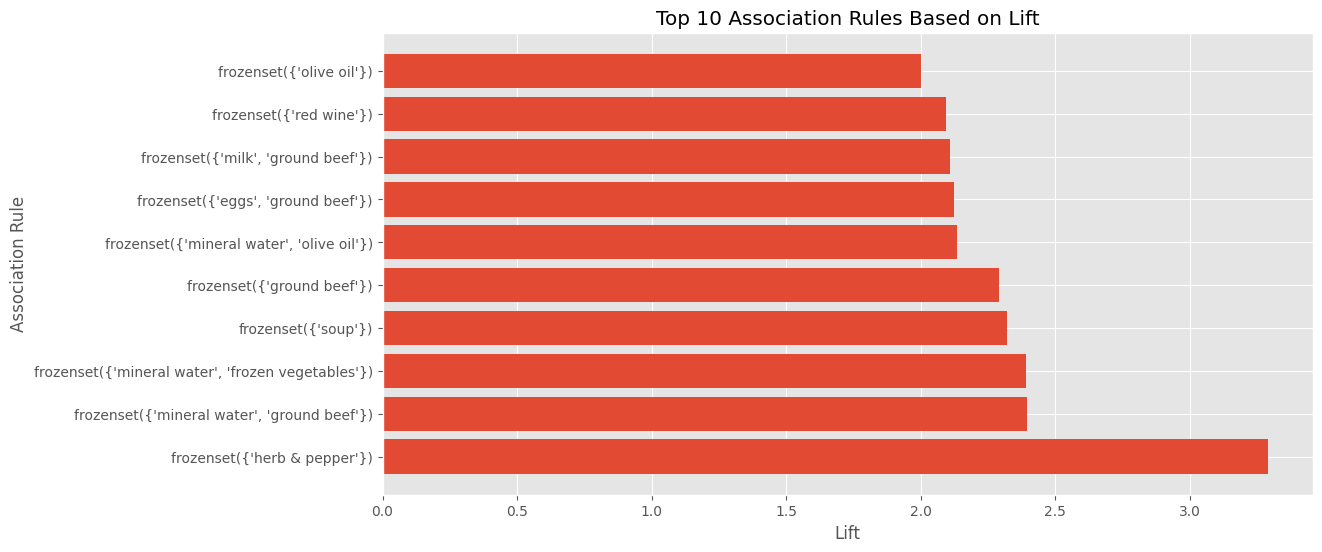

In [94]:
# ==========================================================
# Plot Top 10 Association Rules
# ==========================================================

plt.figure(figsize=(12,6))

plt.barh(

    top_rules["antecedents"].astype(str),

    top_rules["lift"]

)

plt.xlabel("Lift")

plt.ylabel("Association Rule")

plt.title("Top 10 Association Rules Based on Lift")

plt.show()

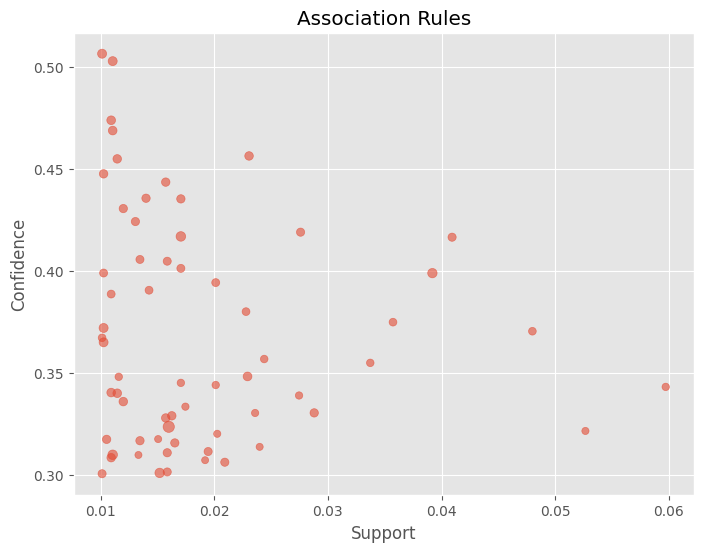

In [95]:
# ==========================================================
# Scatter Plot
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(

    rules["support"],

    rules["confidence"],

    s=rules["lift"]*20,

    alpha=0.6

)

plt.xlabel("Support")

plt.ylabel("Confidence")

plt.title("Association Rules")

plt.show()

### Findings

The Apriori algorithm successfully identified frequent product combinations within the transaction dataset and generated association rules based on Support, Confidence, and Lift.

Products with higher support values appeared more frequently across customer transactions, while rules with higher confidence indicated stronger conditional relationships between purchased items. Furthermore, Lift values greater than 1 suggested positive product associations that may be useful for recommendation systems and cross-selling strategies.